In [3]:
import brainsss
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors
%matplotlib inline
#from sklearn.cluster import AgglomerativeClustering
import scipy
import time
import h5py
import ants
import nibabel as nib
from scipy.ndimage import uniform_filter, gaussian_filter
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import pdist
import shutil
from sklearn.cluster import AgglomerativeClustering, AffinityPropagation
from sklearn.feature_extraction.image import grid_to_graph
import gc
import sys
import warnings
from scipy.ndimage import gaussian_filter1d,gaussian_filter
from scipy.signal import butter, sosfiltfilt, filtfilt, freqz,iirnotch
import cv2
from scipy.ndimage.morphology import binary_erosion
from scipy.ndimage.morphology import binary_dilation
from scipy.ndimage import zoom
from sklearn.mixture import GaussianMixture
import sklearn
from sklearn import metrics
from sklearn.datasets import make_blobs

/home/users/ilanazs/.local/lib/python3.6/site-packages/ants/viz/render_surface_function.py:16: UserWarning:

Cant import Plotly. Install it `pip install chart_studio` if you want to use ants.render_surface_function



In [4]:
def supervoxel_to_full_res(brain, cluster_labels):
    n_clusters = brain.shape[2]
    n_tp = brain.shape[1]
    brain_dims=[314,146]
    
    reformed_brain = []
    for z in range(brain.shape[0]):
        colored_by_betas = np.zeros((n_tp, brain_dims[0]*brain_dims[1]))
        for cluster_num in range(n_clusters):
            cluster_mask = cluster_labels[z,:]==cluster_num
#             print(cluster_indicies)
            colored_by_betas[:,cluster_mask] = brain[z,:,cluster_num,np.newaxis]
        colored_by_betas = colored_by_betas.reshape(n_tp,brain_dims[0],brain_dims[1])
        reformed_brain.append(colored_by_betas)
    return np.asarray(reformed_brain)
def dual_channel_remove_noise(arr_r, arr_g):
    z,xy,t=np.shape(arr_g)
    flat_red=arr_r.reshape(xy*z,t)
    flat_green=arr_g.reshape(xy*z,t)
    print(flat_green.shape)
    flat_sig=np.zeros_like(flat_green)
    for i in range(np.shape(flat_red)[0]):
        a=np.polyfit(flat_red[i,:],flat_green[i,:],1)
        sig = flat_green[i,:] - (a[0]*flat_red[i,:] + a[1])
        flat_sig[i,:]=sig
    return flat_sig.reshape(z,xy,t)
def make_multi_behave_dict(behaviors,later_dir,step_size,event,ch_num):
    behave_dict = {}
    for behavior in behaviors:
        behave_dir = os.path.join(later_dir, behavior)
        behave_dict[behavior]=[]
        for file in os.listdir(behave_dir):
            if 'STA' in file and str(step_size) in file and event in file and f'_{ch_num}_' in file:
                STA_path=os.path.join(behave_dir, file)
                with h5py.File(STA_path, 'r') as sf:
                    brain = sf['data'][:]
                    brain[np.isnan(brain)] = 0
                    brain[np.isinf(brain)] = 4
                    brain = np.moveaxis(brain, 0, -1)
                    dims=np.shape(brain)
                    print(f'brain {file} shape: {dims}')
                    behave_dict[behavior]=brain
    return behave_dict

def make_supervox_dict(behave_dict, behaviors, n_clusters,cluster_labels):
    supervox_dict={}
    for behave in behaviors:
        supervox_dict[behave]=[]
        brain = behave_dict[behave]
        dims = np.shape(brain)
        for z in range(dims[-2]):
            neural_activity = brain[:,:,z,:].reshape(-1, dims[3])
            signals = []
            for cluster_num in range(n_clusters):
                cluster_indicies = np.where(cluster_labels[z,:]==cluster_num)[0]
                mean_signal = np.mean(neural_activity[cluster_indicies,:], axis=0)
                signals.append(mean_signal)
            signals = np.asarray(signals)
            supervox_dict[behave].append(signals)
        supervox_dict[behave] = np.asarray(supervox_dict[behave])
        print(f'{behave} shape: {np.shape(supervox_dict[behave])}')
    return supervox_dict
def supervoxel_to_full_res(brain, cluster_labels):
    n_clusters = brain.shape[2]
    n_tp = brain.shape[1]
    brain_dims=[314,146]
    
    reformed_brain = []
    for z in range(brain.shape[0]):
        colored_by_betas = np.zeros((n_tp, brain_dims[0]*brain_dims[1]))
        for cluster_num in range(n_clusters):
            cluster_mask = cluster_labels[z,:]==cluster_num
#             print(cluster_indicies)
            colored_by_betas[:,cluster_mask] = brain[z,:,cluster_num,np.newaxis]
        colored_by_betas = colored_by_betas.reshape(n_tp,brain_dims[0],brain_dims[1])
        reformed_brain.append(colored_by_betas)
    return np.asarray(reformed_brain)

In [5]:
### big STA supervox
later_dir = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter'
cluster_dir = os.path.join(later_dir, 'clustering')
save_dir=os.path.join(later_dir,'figs')

behaviors = ['total', 'inc', 'dec', 'flat']

n_clusters=2000

step_size=100

event='10flies'

ch_g=2
ch_r=1

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [6]:
giant_cluster_labels = np.load(os.path.join(cluster_dir, 'cluster_labels_best_flies.npy'))

# Load STAs for each behavior and channel

In [7]:
behave_dict_g = make_multi_behave_dict(behaviors,later_dir,step_size,event,ch_g)
behave_dict_r = make_multi_behave_dict(behaviors,later_dir,step_size,event,ch_r)

brain STA_2_total_100_10flies.h5 shape: (314, 146, 91, 24)
brain STA_2_inc_100_10flies.h5 shape: (314, 146, 91, 24)
brain STA_2_dec_100_10flies.h5 shape: (314, 146, 91, 24)
brain STA_2_flat_100_10flies.h5 shape: (314, 146, 91, 24)
brain STA_1_total_100_10flies.h5 shape: (314, 146, 91, 24)
brain STA_1_inc_100_10flies.h5 shape: (314, 146, 91, 24)
brain STA_1_dec_100_10flies.h5 shape: (314, 146, 91, 24)
brain STA_1_flat_100_10flies.h5 shape: (314, 146, 91, 24)


In [8]:
behave_dict_g.keys()

dict_keys(['total', 'inc', 'dec', 'flat'])

# Turn both channel STA dicts into Supervoxels

In [9]:
%%time
supervox_dict_g=make_supervox_dict(behave_dict_g, behaviors, n_clusters,giant_cluster_labels)
supervox_dict_r=make_supervox_dict(behave_dict_r, behaviors, n_clusters,giant_cluster_labels)

total shape: (91, 2000, 24)
inc shape: (91, 2000, 24)
dec shape: (91, 2000, 24)
flat shape: (91, 2000, 24)
total shape: (91, 2000, 24)
inc shape: (91, 2000, 24)
dec shape: (91, 2000, 24)
flat shape: (91, 2000, 24)
CPU times: user 48 s, sys: 264 ms, total: 48.3 s
Wall time: 48.3 s


# Remove noise using red channel regression

In [10]:
%%time
supervox_dict_total={}
for behave in behaviors:
    print(behave)
    arr_g=supervox_dict_g[behave]
    arr_r=supervox_dict_r[behave]
    total_behave=dual_channel_remove_noise(arr_r, arr_g)
    supervox_dict_total[behave]=total_behave

total
(182000, 24)
inc
(182000, 24)
dec
(182000, 24)
flat
(182000, 24)
CPU times: user 50.9 s, sys: 982 ms, total: 51.9 s
Wall time: 49.8 s


# Put the Supervoxs back into anatomical space

In [11]:
%%time
full_res={}
for behave in behaviors:
    print(behave)
#     supervox_brain=lowpass_dict[behave]
#     supervox_brain=gaussian_filter(supervox_dict_total[behave], sigma=1.5)
    supervox_brain=np.moveaxis(supervox_dict_total[behave],-1,-2)
#     print(np.shape(supervox_brain))
    full_res_brain=supervoxel_to_full_res(supervox_brain, giant_cluster_labels)
    full_res_brain=np.moveaxis(full_res_brain, 0,-1)
#     full_res_brain=np.moveaxis(full_res_brain, 0,-1)
    print(np.shape(full_res_brain))
    full_res[behave]=np.asarray(full_res_brain)

total
(24, 314, 146, 91)
inc
(24, 314, 146, 91)
dec
(24, 314, 146, 91)
flat
(24, 314, 146, 91)
CPU times: user 48.6 s, sys: 1.2 s, total: 49.8 s
Wall time: 49.8 s


In [12]:
# fixed = brainsss.load_fda_meanbrain()
# brain=full_res['total']
# smoothed=gaussian_filter(brain, sigma=1.5)
# # masked=np.where(fixed.numpy()[...,None]>0.1, brain, np.nan)
# masked=np.where(fixed.numpy()[None,...]>0.1,smoothed, np.nan)

In [13]:
atlas = brainsss.load_roi_atlas()
explosion_rois = brainsss.load_explosion_groups()
all_rois = brainsss.unnest_roi_groups(explosion_rois)
roi_masks = brainsss.make_single_roi_masks(all_rois, atlas)
roi_contours = brainsss.make_single_roi_contours(roi_masks, atlas)

In [14]:
behavior='total'
full_res[behavior].shape

(24, 314, 146, 91)

In [15]:
total_vox_sorted={}
for behavior in full_res:
    STA=full_res[behavior]
    total_vox_sorted[behavior]={}
    for area in explosion_rois:
        for key in explosion_rois[area]['rois']:
            area_name=explosion_rois[area]['rois'][key]
            if '_R' in area_name or '_L' in area_name:
                total_area_name=area_name.split('_')
                if len(total_area_name)==3:
                    area_name=total_area_name[0]+'_'+total_area_name[1]
                else:
                    area_name=total_area_name[0]
            roi=key
            roi_mask=roi_masks[roi]
            masked_roi=[STA[i][roi_mask] for i in range(np.shape(STA)[0])]
            masked_roi=np.transpose(masked_roi)
    #         roi_sort=sort_rows_by_max_index(masked_roi)
            try:
                np.append(total_vox_sorted[behavior][area_name], masked_roi)
            except KeyError:
                total_vox_sorted[behavior][area_name]=masked_roi

In [16]:
def moving_average_2d(arr):
    num_bins=np.shape(arr)[-1]
    window_size=int(num_bins/5)
    # Apply uniform filter to compute the moving average
    return uniform_filter(arr, size=window_size, mode='constant')

def sort_rows_by_max_index(arr):
    smoothed_row=moving_average_2d(arr)
    max_stim=[]
    max_not_stim=[]
    for i,row in enumerate(smoothed_row):
        loc=np.where(row==np.nanmax(row))[0][0]
    #     print(loc)
        if loc>5:
            max_stim.append(arr[i])
        else:
            max_not_stim.append(arr[i])
    max_stim=np.asarray(max_stim)
    max_not_stim=np.asarray(max_not_stim)
    if max_stim.size>0 and max_not_stim.size>0:
        max_indices_stim = np.nanargmax(max_stim, axis=1)
        max_indices_notstim = np.nanargmax(max_not_stim, axis=1)
        # Get the sorted order of the rows based on the max indices
        sorted_order_stim = np.argsort(max_indices_stim)
        sorted_order_notstim = np.argsort(max_indices_notstim)
        # Sort the rows of the array based on the sorted order
        sorted_arr_stim = max_stim[sorted_order_stim,:]
        sorted_arr_notstim = max_not_stim[sorted_order_notstim,:]

        sorted_arr=np.vstack([sorted_arr_stim,sorted_arr_notstim])
    elif max_stim.size==0:
        max_indices_notstim = np.nanargmax(max_not_stim, axis=1)
        # Get the sorted order of the rows based on the max indices
        sorted_order_notstim = np.argsort(max_indices_notstim)
        # Sort the rows of the array based on the sorted order
        sorted_arr = max_not_stim[sorted_order_notstim,:]
    elif max_not_stim.size==0:
        max_indices_stim = np.nanargmax(max_stim, axis=1)
        
        # Get the sorted order of the rows based on the max indices
        sorted_order_stim = np.argsort(max_indices_stim)
        
        # Sort the rows of the array based on the sorted order
        sorted_arr = max_stim[sorted_order_stim,:]
    return sorted_arr

In [17]:
%%time
for behavior in total_vox_sorted:
    for key in total_vox_sorted[behavior]:
        total_vox_sorted[behavior][key]=sort_rows_by_max_index(total_vox_sorted[behavior][key])

CPU times: user 21.1 s, sys: 401 ms, total: 21.5 s
Wall time: 21 s


In [18]:
anat_avgs_z={}
for behavior in total_vox_sorted:
    bbrain=total_vox_sorted[behavior]
    anat_avgs_z[behavior]={}
    for anat in bbrain:
        n,t=np.shape(bbrain[anat])
        mean = (np.mean(bbrain[anat], axis=0))
        z=scipy.stats.zscore(mean,axis=-1)
        anat_avgs_z[behavior][anat]=z
#         mean = (np.mean(bbrain[anat], axis=0))


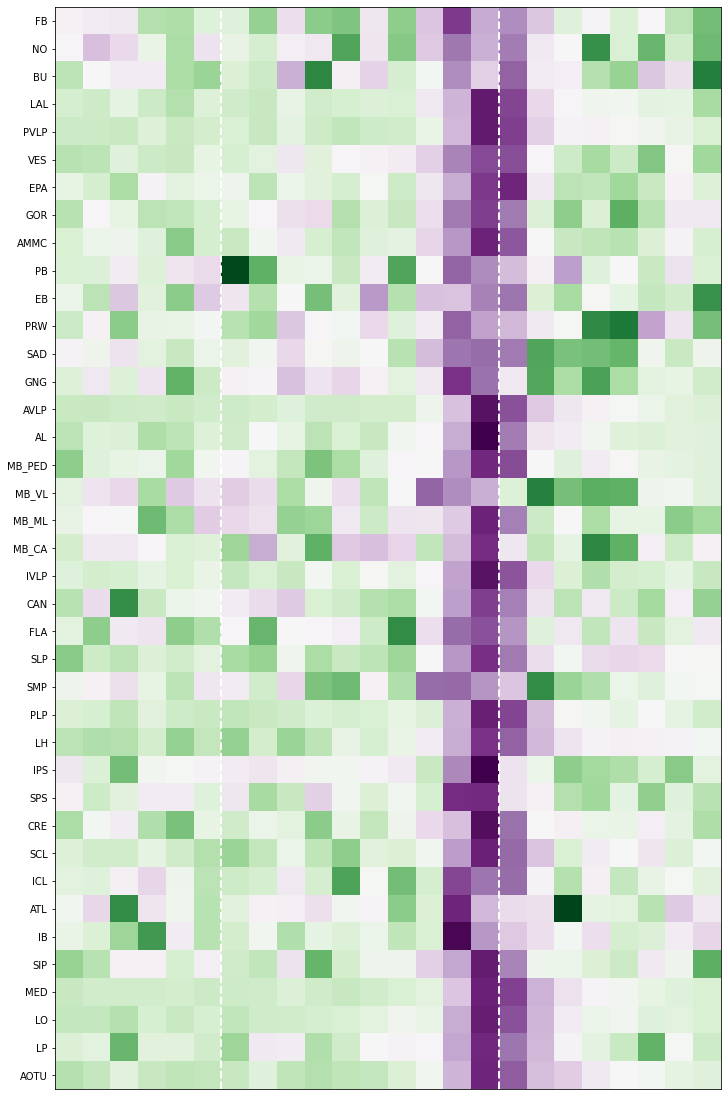

In [19]:
avg_behave=anat_avgs_z['total']
# avg_behave=maxes
# vmax=3
# norm = matplotlib.colors.Normalize(vmin=-vmax, vmax=vmax)
# final = norm(data_map)
fig,axs = plt.subplots(figsize=(10,20),sharex='col', sharey=False)
fig.subplots_adjust(right=1.05)
# twin=axs.twinx()
# for i,key in enumerate(avg_behave)
# axs.imshow(avg_behave.values(),vmax=2.5,vmin=-3, cmap='seismic')
avg=axs.imshow(avg_behave.values(), norm=colors.DivergingNorm(0), cmap='PRGn_r')
# axs.imshow(avg_behave.values(),vmax=30,cmap='magma')
# axs.set_ylabel(avg_behave.keys())
# for ax in axs:
# axs.label_outer()
# axs.spines['left'].set_visible(False)
# axs.spines['right'].set_visible(False)
# axs.set_aspect(1)
axs.axvline(x=5.5, ymin=0, ymax=1, ls='--', color='w', lw=2)
axs.axvline(x=15.5, ymin=0, ymax=1, ls='--', color='w', lw=2)
axs.set_yticks(np.arange(len(list(avg_behave.keys()))))
axs.set_yticklabels(list(avg_behave.keys()))
# twin.set_yticks(np.arange(len(list(avg_behave.keys()))))
# twin.set_yticklabels(max_vals[::-1])
axs.set_xticks([])

# fig.colorbar(avg)

# plt.savefig(os.path.join(save_dir,f'avg_anat_heatmap_{step_size}.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)
        
plt.show()

In [20]:
# avg_behave_z=anat_avgs_z['total']
# avg_behave_m=maxes

cmat_h=np.corrcoef(list(avg_behave.values()))
# cmat_z=np.corrcoef(list(avg_behave_z.values()))
# cmat_m=np.corrcoef(list(avg_behave_m.values()))
# cmat=np.cov(list(gain.values()))
np.shape(cmat_h)

(39, 39)

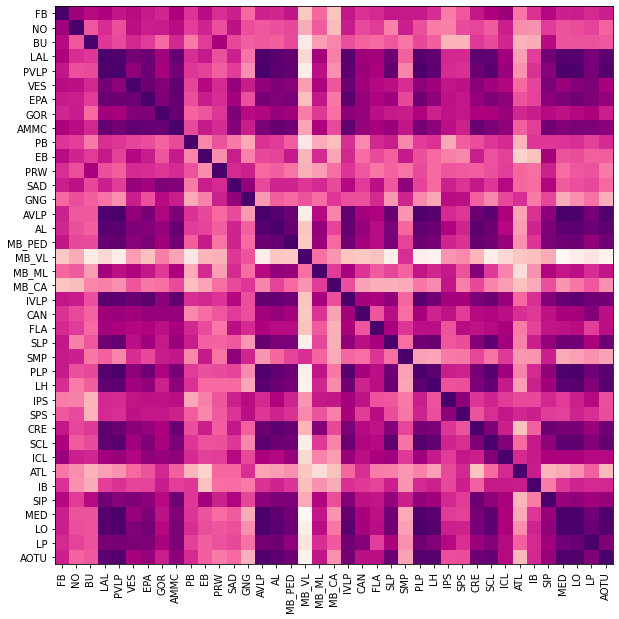

In [21]:
fig,axs = plt.subplots(figsize=(10,100))
axs.imshow(cmat_h, cmap='RdPu');
axs.label_outer();
axs.set_aspect(1);
axs.set_yticks(np.arange(len(list(avg_behave.keys()))));
axs.set_yticklabels(list(avg_behave.keys()));
axs.set_xticks(np.arange(len(list(avg_behave.keys()))));
axs.set_xticklabels(list(avg_behave.keys()), rotation='vertical');

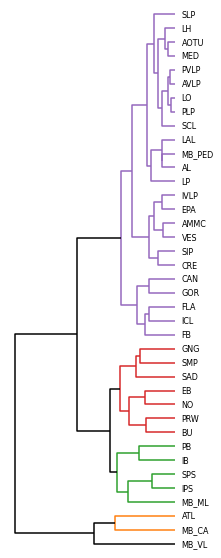

In [22]:
# dist_matrix_z = 1 - cmat_z
# dist_matrix_m = 1 - cmat_m
dist_matrix = 1 - cmat_h
# linkage = sch.linkage(pdist(cmat), method='average')
# linkage_z= sch.linkage(pdist(cmat_z),method='complete',metric='euclidean',optimal_ordering=True)
# linkage_m= sch.linkage(pdist(cmat_m),method='complete',metric='euclidean',optimal_ordering=True)
linkage= sch.linkage(pdist(cmat_h),method='complete',metric='euclidean',optimal_ordering=True)

# print(linkage_z==linkage_m)

# colors=['b','g','y','m']

fig,axs = plt.subplots(figsize=(3, 10))
sch.dendrogram(linkage, p=len(list(avg_behave.keys())), truncate_mode='lastp', ax=axs, above_threshold_color='black',
               color_threshold=1.5, orientation='left',labels=list(avg_behave.keys()))
# sch.dendrogram(linkage, labels=list(avg_behave.keys()))
# plt.title('Hierarchical Clustering Based on Correlation')
axs.set_xticks([])
axs.spines['top'].set_visible(False)
axs.spines['right'].set_visible(False)
axs.spines['bottom'].set_visible(False)
axs.spines['left'].set_visible(False)
plt.show()

In [23]:
# Get cluster assignments for a specific cut height
# clusters = sch.fcluster(linkage, t=0.5, criterion='distance')
clusters = sch.fcluster(linkage, t=1.5, criterion='distance')

In [24]:
clusters

array([5, 4, 4, 5, 5, 5, 5, 5, 5, 3, 4, 4, 4, 4, 5, 5, 5, 2, 3, 1, 5, 5,
       5, 5, 4, 5, 5, 3, 3, 5, 5, 5, 1, 3, 5, 5, 5, 5, 5], dtype=int32)

In [25]:
print(np.shape(list(avg_behave.keys())))
avg_behave.keys()

(39,)


dict_keys(['FB', 'NO', 'BU', 'LAL', 'PVLP', 'VES', 'EPA', 'GOR', 'AMMC', 'PB', 'EB', 'PRW', 'SAD', 'GNG', 'AVLP', 'AL', 'MB_PED', 'MB_VL', 'MB_ML', 'MB_CA', 'IVLP', 'CAN', 'FLA', 'SLP', 'SMP', 'PLP', 'LH', 'IPS', 'SPS', 'CRE', 'SCL', 'ICL', 'ATL', 'IB', 'SIP', 'MED', 'LO', 'LP', 'AOTU'])

In [26]:
to_sort=avg_behave #for normalized
# to_sort=anat_avgs['total'] #for OG
clustered={}
clus_num=list(np.unique(clusters))
for val in clus_num:
    clustered[val]={}
    print(val)
    for i, anat in enumerate(to_sort):
#         print(i, anat)
        cluster_val=clusters[i]
        if cluster_val==val:
            clustered[val][anat]=to_sort[anat]

1
2
3
4
5


In [27]:
temp_clustered_final={}
cluster_dict=clustered
# name_mean=[]
for cluster in clustered:
    cluster=cluster-1
    temp_clustered_final[cluster]={}
    sort_idx=np.argsort(np.mean(list(cluster_dict[cluster+1].values()), axis=1))
    print(sort_idx)
    names=list(cluster_dict[cluster+1].keys())
    for idx in sort_idx:
        key=names[idx]
#         print(key)
        temp_clustered_final[cluster][key]=cluster_dict[cluster+1][key]
#         name_mean.append(key)

[0 1]
[0]
[2 3 1 4 0]
[0 1 3 4 2 5 6]
[12  3 13  5 14 17 10  7 15 23 18 21  2  1  9 22  6 20  0 19  8  4 16 11]


In [28]:
temp_clustered_final.keys()

dict_keys([0, 1, 2, 3, 4])

In [29]:
area_size=[]
for clust in temp_clustered_final:
    print(list(temp_clustered_final[clust].keys()))
    area_size.append(len(temp_clustered_final[clust].keys()))
order=np.argsort(area_size)

['MB_CA', 'ATL']
['MB_VL']
['IPS', 'SPS', 'MB_ML', 'IB', 'PB']
['NO', 'BU', 'PRW', 'SAD', 'EB', 'GNG', 'SMP']
['FLA', 'VES', 'SLP', 'GOR', 'PLP', 'SCL', 'IVLP', 'AVLP', 'LH', 'AOTU', 'ICL', 'LO', 'PVLP', 'LAL', 'MB_PED', 'LP', 'AMMC', 'MED', 'FB', 'SIP', 'AL', 'EPA', 'CRE', 'CAN']


In [30]:
order

array([1, 0, 2, 3, 4])

In [31]:
h_clustered={}
for val in order:
    c=temp_clustered_final[val]
    for name in c:
        h_clustered[name]=c[name]

In [32]:
len(h_clustered.keys())

39

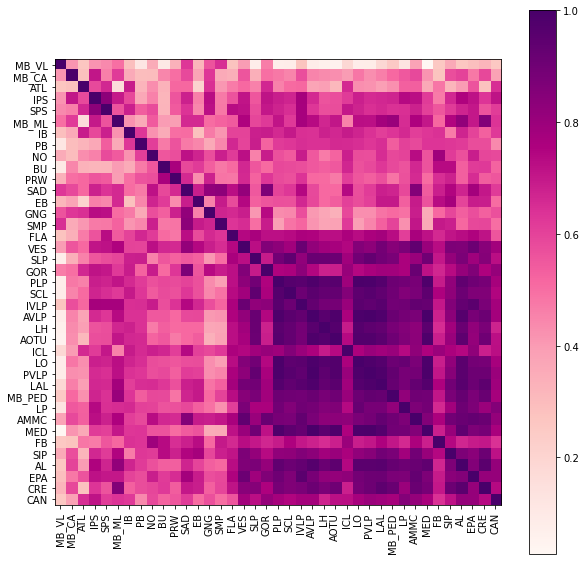

In [33]:
cmat_ht=np.corrcoef(list(h_clustered.values()))
fig,axs = plt.subplots(figsize=(10,10))
cov=axs.imshow(cmat_ht, cmap='RdPu');
axs.label_outer();
axs.set_aspect(1);
axs.set_yticks(np.arange(len(list(h_clustered.keys()))));
axs.set_yticklabels(list(h_clustered.keys()));
axs.set_xticks(np.arange(len(list(h_clustered.keys()))));
axs.set_xticklabels(list(h_clustered.keys()), rotation='vertical');
fig.colorbar(cov);

In [34]:
data=np.asarray(list(h_clustered.values()))
iterations = 100
cmat_shuffled = []
for it in range(iterations):
    idx = np.random.rand(*data.T.shape).argsort(0)
    data_shuffled = data.T[idx, np.arange(data.T.shape[1])].T

    cmat_shuffled.append(np.corrcoef(data_shuffled))
cmat_shuffled = np.mean(np.stack(cmat_shuffled, axis=-1), axis=-1)  # average across iterations


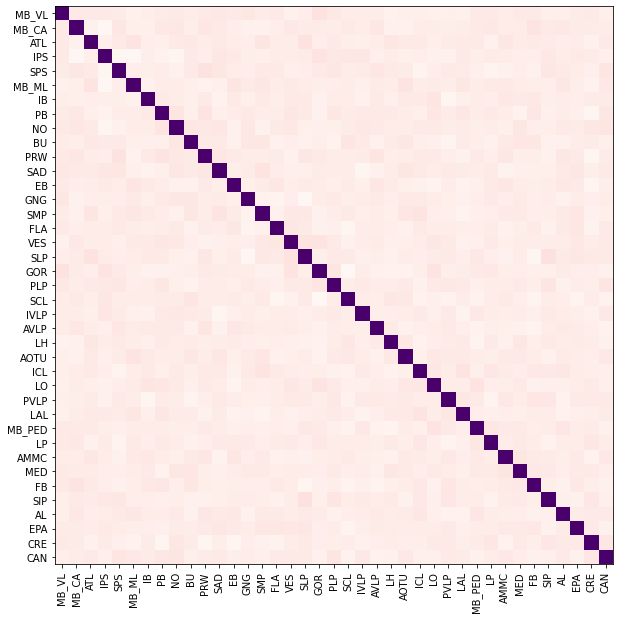

In [35]:
fig,axs = plt.subplots(figsize=(10,100))
axs.imshow(cmat_shuffled, cmap='RdPu');
axs.label_outer();
axs.set_aspect(1);
axs.set_yticks(np.arange(len(list(avg_behave.keys()))));
axs.set_yticklabels(list(h_clustered.keys()));
axs.set_xticks(np.arange(len(list(avg_behave.keys()))));
axs.set_xticklabels(list(h_clustered.keys()), rotation='vertical');

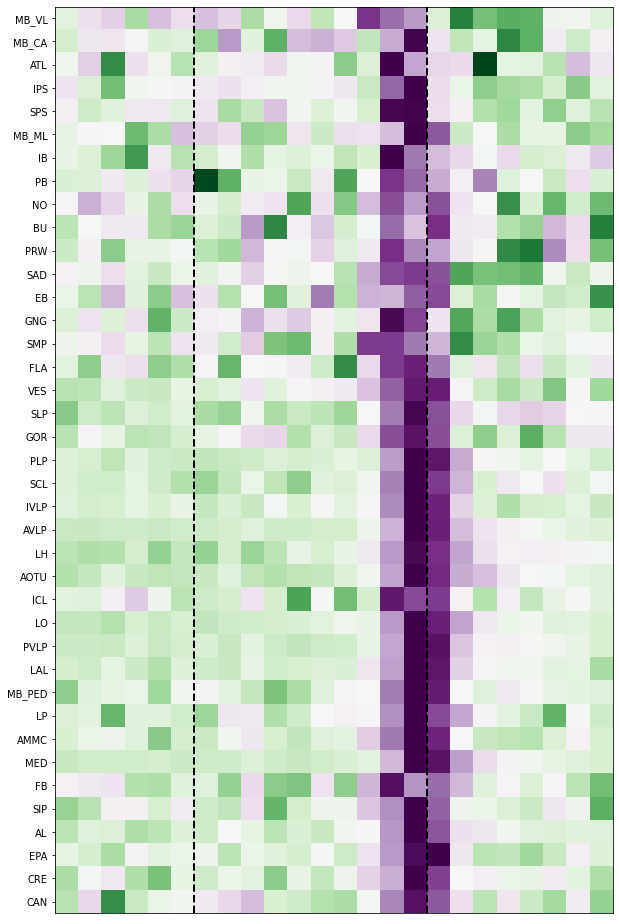

In [36]:
to_plot=h_clustered
vmax=3
# norm = matplotlib.colors.Normalize(vmin=-vmax, vmax=vmax)
# final = norm(data_map)
fig,axs = plt.subplots(figsize=(10,20),sharex='col', sharey=False)
# for i,key in enumerate(avg_behave)
# axs.imshow(avg_behave.values(),vmax=2.5,vmin=-3, cmap='magma')
plts=axs.imshow(to_plot.values(),norm=colors.DivergingNorm(0), vmax=vmax, cmap='PRGn_r')
# axs.set_ylabel(avg_behave.keys())
# for ax in axs:
axs.label_outer()
# axs.spines['left'].set_visible(False)
# axs.spines['right'].set_visible(False)
axs.set_aspect(1)
axs.axvline(x=5.5, ymin=0, ymax=1, ls='--', color='k', lw=2)
axs.axvline(x=15.5, ymin=0, ymax=1, ls='--', color='k', lw=2)
axs.set_yticks(np.arange(len(list(to_plot.keys()))))
axs.set_yticklabels(list(to_plot.keys()))
axs.set_xticks([])
# fig.colorbar(plts)

# plt.savefig(os.path.join(save_dir,f'avg_anat_heatmap_{step_size}.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)
        
plt.show()

In [37]:
dist_matrix.shape

(39, 39)

In [38]:
X=dist_matrix
af = AffinityPropagation(preference=-2, random_state=0).fit(X)
cluster_centers_indices = af.cluster_centers_indices_
labels = af.labels_

In [39]:
n_clusters_ = len(cluster_centers_indices)

<Figure size 432x288 with 0 Axes>

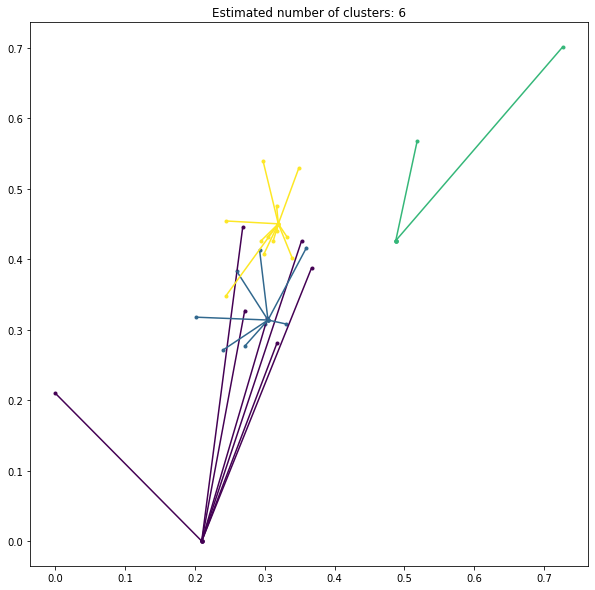

In [40]:
plt.close("all")
plt.figure(1)
plt.clf()

plt.subplots(figsize=(10,10))

colors_clust = plt.cycler("color", plt.cm.viridis(np.linspace(0, 1, 4)))

for k, col in zip(range(n_clusters_), colors_clust):
    class_members = labels == k
    cluster_center = X[cluster_centers_indices[k]]
    plt.scatter(
        X[class_members, 0], X[class_members, 1], color=col["color"], marker="."
    )
    plt.scatter(
        cluster_center[0], cluster_center[1], s=14, color=col["color"], marker="o"
    )
    for x in X[class_members]:
        plt.plot(
            [cluster_center[0], x[0]], [cluster_center[1], x[1]], color=col["color"]
        )

plt.title("Estimated number of clusters: %d" % n_clusters_);
plt.show();

In [41]:
to_sort=avg_behave #for normalized
# to_sort=anat_avgs['total'] #for OG
temp_clustered={}
clus_num=list(np.unique(labels))
for val in clus_num:
    temp_clustered[val]={}
    print(val)
    for i, anat in enumerate(to_sort):
#         print(i, anat)
        cluster_val=labels[i]
        if cluster_val==val:
            temp_clustered[val][anat]=to_sort[anat]

0
1
2
3
4
5


In [42]:
for key in temp_clustered:
    print(f'Cluster {key}: {temp_clustered[key].keys()}')

Cluster 0: dict_keys(['FB', 'NO', 'BU', 'PB', 'EB', 'PRW', 'SAD', 'SMP'])
Cluster 1: dict_keys(['VES', 'EPA', 'GOR', 'AMMC', 'MB_PED', 'IVLP', 'CAN', 'ICL', 'SIP'])
Cluster 2: dict_keys(['GNG', 'MB_CA', 'ATL'])
Cluster 3: dict_keys(['LAL', 'PVLP', 'AVLP', 'AL', 'SLP', 'PLP', 'LH', 'CRE', 'SCL', 'MED', 'LO', 'LP', 'AOTU'])
Cluster 4: dict_keys(['MB_VL'])
Cluster 5: dict_keys(['MB_ML', 'FLA', 'IPS', 'SPS', 'IB'])


In [43]:
np.mean(list(temp_clustered[0].values()))

1.850371707708594e-17

In [44]:
# means=[]
# for clust in temp_clustered:
#     clust_mean=np.mean(list(temp_clustered[clust].values()))
#     means.append(clust_mean)
# order=np.argsort(means)
# temp_clustered_final={}
# for i in range(len(order)):
#     clust=order[i]
#     temp_clustered_final[clust]=temp_clustered[clust]

In [45]:
# print(temp_clustered.keys())
# print(temp_clustered_final.keys())

In [46]:
temp_clustered_final={}
cluster_dict=temp_clustered
# name_mean=[]
for cluster in temp_clustered:
    temp_clustered_final[cluster]={}
    sort_idx=np.argsort(np.mean(list(cluster_dict[cluster].values()), axis=1))
    print(sort_idx)
    names=list(cluster_dict[cluster].keys())
    for idx in sort_idx:
        key=names[idx]
#         print(key)
        temp_clustered_final[cluster][key]=cluster_dict[cluster][key]
#         name_mean.append(key)

[1 2 5 6 3 4 0 7]
[0 2 5 4 7 3 8 1 6]
[1 0 2]
[ 4  5  8  2  0  1  6 10 12 11  9  3  7]
[0]
[2 1 3 0 4]


In [47]:
temp_clustered_final.keys()

dict_keys([0, 1, 2, 3, 4, 5])

In [48]:
area_size=[]
for clust in temp_clustered_final:
    print(list(temp_clustered_final[clust].keys()))
    area_size.append(len(temp_clustered_final[clust].keys()))
order=np.argsort(area_size)

['NO', 'BU', 'PRW', 'SAD', 'PB', 'EB', 'FB', 'SMP']
['VES', 'GOR', 'IVLP', 'MB_PED', 'ICL', 'AMMC', 'SIP', 'EPA', 'CAN']
['MB_CA', 'GNG', 'ATL']
['SLP', 'PLP', 'SCL', 'AVLP', 'LAL', 'PVLP', 'LH', 'LO', 'AOTU', 'LP', 'MED', 'AL', 'CRE']
['MB_VL']
['IPS', 'FLA', 'SPS', 'MB_ML', 'IB']


In [49]:
ap_clustered={}
for val in order:
    c=temp_clustered_final[val]
    for name in c:
        ap_clustered[name]=c[name]

In [50]:
ap_clustered.keys()

dict_keys(['MB_VL', 'MB_CA', 'GNG', 'ATL', 'IPS', 'FLA', 'SPS', 'MB_ML', 'IB', 'NO', 'BU', 'PRW', 'SAD', 'PB', 'EB', 'FB', 'SMP', 'VES', 'GOR', 'IVLP', 'MB_PED', 'ICL', 'AMMC', 'SIP', 'EPA', 'CAN', 'SLP', 'PLP', 'SCL', 'AVLP', 'LAL', 'PVLP', 'LH', 'LO', 'AOTU', 'LP', 'MED', 'AL', 'CRE'])

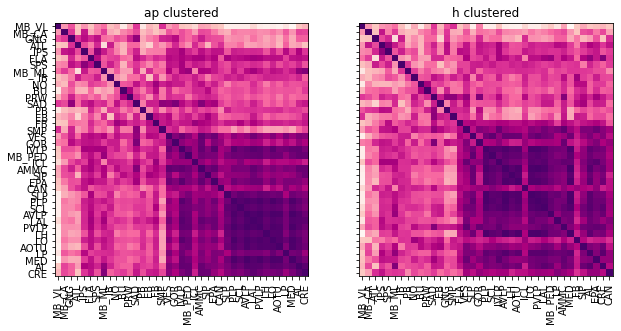

In [51]:
cmat_ap=np.corrcoef(list(ap_clustered.values()))
# cmat_ap=np.corrcoef(ap_clustered)
# print(np.shape(cmat_ap))
fig,axs = plt.subplots(1,2,figsize=(10,10))
cov=axs[0].imshow(cmat_ap, cmap='RdPu');
axs[0].label_outer();
axs[0].set_aspect(1);
axs[0].set_yticks(np.arange(len(list(ap_clustered.keys()))));
axs[0].set_yticklabels(list(ap_clustered.keys()));
axs[0].set_xticks(np.arange(len(list(ap_clustered.keys()))));
axs[0].set_xticklabels(list(ap_clustered.keys()), rotation='vertical');
cmat_h=np.corrcoef(list(h_clustered.values()))
cov=axs[1].imshow(cmat_h, cmap='RdPu');
axs[1].label_outer();
axs[1].set_aspect(1);
axs[1].set_yticks(np.arange(len(list(h_clustered.keys()))));
axs[1].set_yticklabels(list(h_clustered.keys()));
axs[1].set_xticks(np.arange(len(list(h_clustered.keys()))));
axs[1].set_xticklabels(list(h_clustered.keys()), rotation='vertical');
axs[0].set_title('ap clustered');
axs[1].set_title('h clustered');
# fig.colorbar(cov);

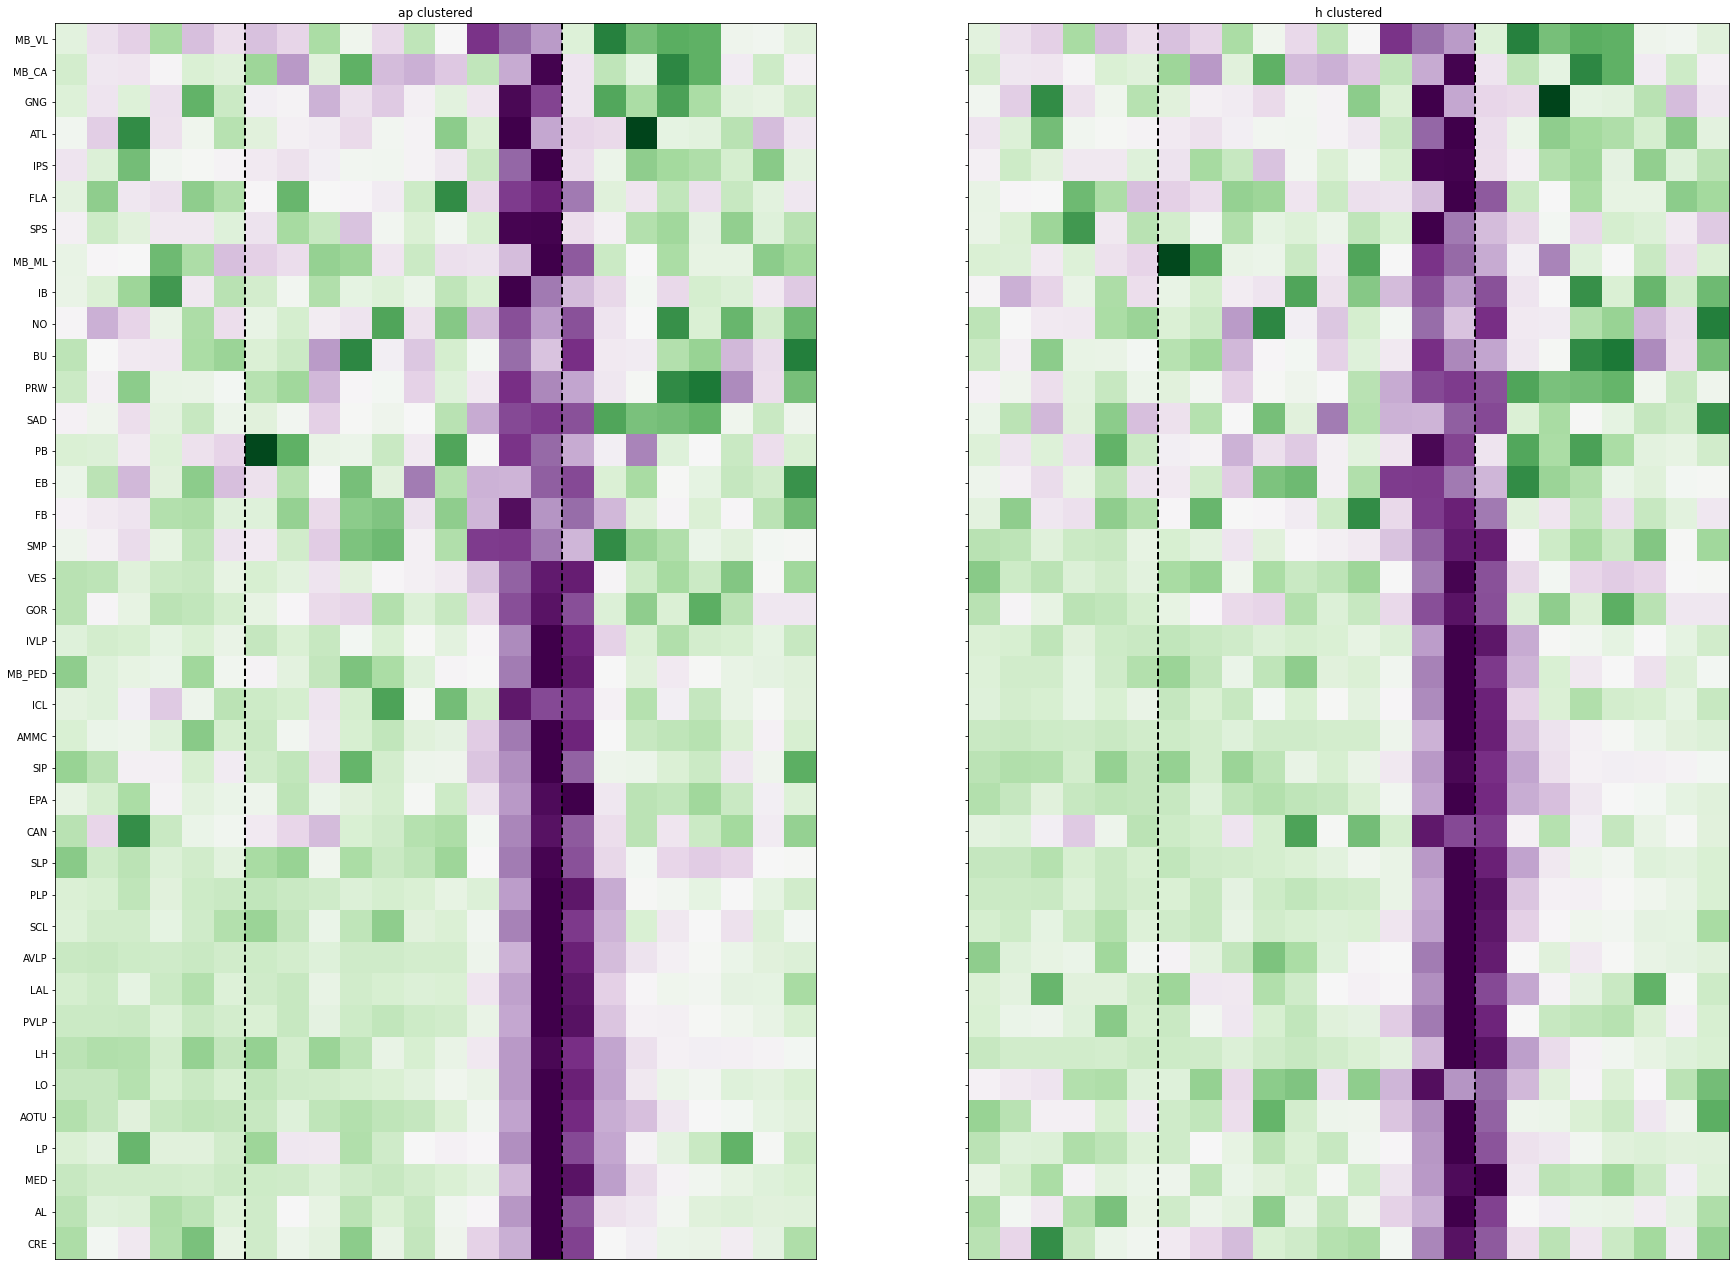

In [52]:
vmax=3
# norm = matplotlib.colors.Normalize(vmin=-vmax, vmax=vmax)
# final = norm(data_map)
fig,axs = plt.subplots(1,2,figsize=(30,60),sharex='col', sharey=False)
# for i,key in enumerate(avg_behave)
# axs.imshow(avg_behave.values(),vmax=2.5,vmin=-3, cmap='magma')
to_plot=ap_clustered
plts=axs[0].imshow(ap_clustered.values(),norm=colors.DivergingNorm(0), vmax=vmax, cmap='PRGn_r')
# axs.set_ylabel(avg_behave.keys())
# for ax in axs:
axs[0].label_outer()
# axs.spines['left'].set_visible(False)
# axs.spines['right'].set_visible(False)
axs[0].set_aspect(1)
axs[0].axvline(x=5.5, ymin=0, ymax=1, ls='--', color='k', lw=2)
axs[0].axvline(x=15.5, ymin=0, ymax=1, ls='--', color='k', lw=2)
axs[0].set_yticks(np.arange(len(list(ap_clustered.keys()))))
axs[0].set_yticklabels(list(ap_clustered.keys()))
axs[0].set_xticks([])
axs[0].set_title('ap clustered')
plts=axs[1].imshow(h_clustered.values(),norm=colors.DivergingNorm(0), vmax=vmax, cmap='PRGn_r')
# axs.set_ylabel(avg_behave.keys())
# for ax in axs:
axs[1].label_outer()
# axs.spines['left'].set_visible(False)
# axs.spines['right'].set_visible(False)
axs[1].set_aspect(1)
axs[1].axvline(x=5.5, ymin=0, ymax=1, ls='--', color='k', lw=2)
axs[1].axvline(x=15.5, ymin=0, ymax=1, ls='--', color='k', lw=2)
axs[1].set_yticks(np.arange(len(list(h_clustered.keys()))))
axs[1].set_yticklabels(list(h_clustered.keys()))
axs[1].set_xticks([])
axs[1].set_title('h clustered')
# fig.colorbar(plts)

# plt.savefig(os.path.join(save_dir,f'avg_anat_heatmap_{step_size}.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)
        
plt.show()

In [53]:
before=np.asarray(list(avg_behave.values()))[...,:6]
during=np.asarray(list(avg_behave.values()))[...,6:16]
after=np.asarray(list(avg_behave.values()))[...,16:]

In [54]:
# avg_behave_z=anat_avgs_z['total']
# avg_behave_m=maxes

cmat_total=np.corrcoef(list(avg_behave.values()))
cmat_before=np.corrcoef(list(before))
cmat_during=np.corrcoef(list(during))
cmat_after=np.corrcoef(list(after))
# cmat_z=np.corrcoef(list(avg_behave_z.values()))
# cmat_m=np.corrcoef(list(avg_behave_m.values()))
# cmat=np.cov(list(gain.values()))
np.shape(cmat_total)

(39, 39)

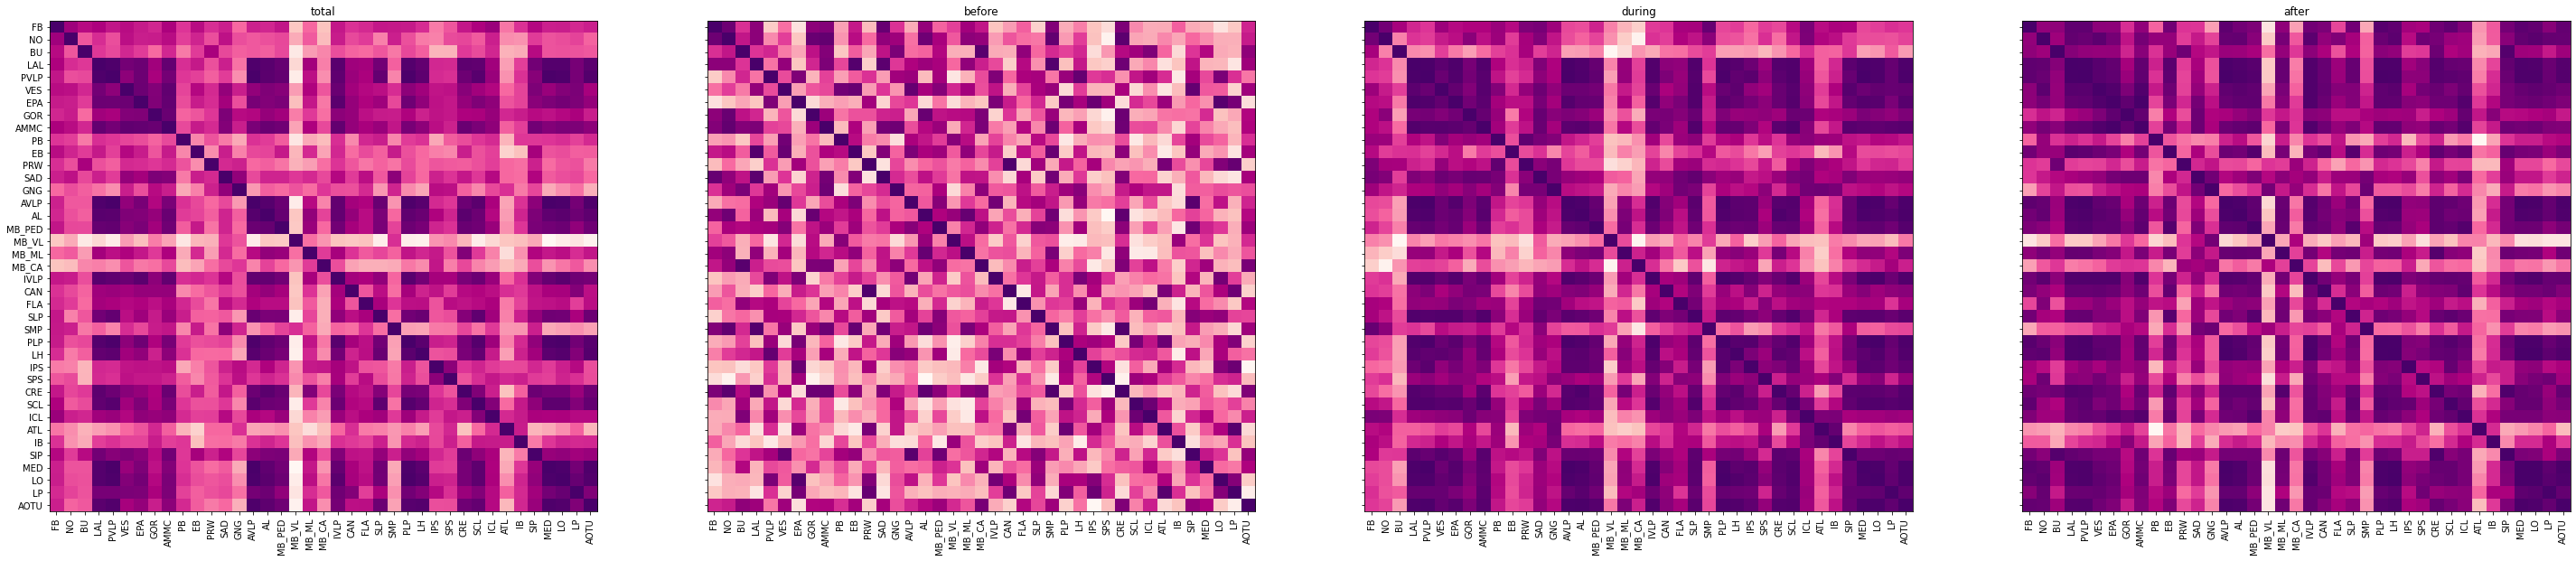

In [55]:
fig,axs = plt.subplots(1,4,figsize=(50,10))
axs[0].imshow(cmat_total, cmap='RdPu');
axs[0].label_outer();
axs[0].set_aspect('auto');
axs[0].set_yticks(np.arange(len(list(avg_behave.keys()))));
axs[0].set_yticklabels(list(avg_behave.keys()));
axs[0].set_xticks(np.arange(len(list(avg_behave.keys()))));
axs[0].set_xticklabels(list(avg_behave.keys()), rotation='vertical');
axs[0].set_title('total')
axs[1].imshow(cmat_before, cmap='RdPu');
axs[1].label_outer();
axs[1].set_aspect('auto');
axs[1].set_yticks(np.arange(len(list(avg_behave.keys()))));
axs[1].set_yticklabels(list(avg_behave.keys()));
axs[1].set_xticks(np.arange(len(list(avg_behave.keys()))));
axs[1].set_xticklabels(list(avg_behave.keys()), rotation='vertical');
axs[1].set_title('before')
axs[2].imshow(cmat_during, cmap='RdPu');
axs[2].label_outer();
axs[2].set_aspect('auto');
axs[2].set_yticks(np.arange(len(list(avg_behave.keys()))));
axs[2].set_yticklabels(list(avg_behave.keys()));
axs[2].set_xticks(np.arange(len(list(avg_behave.keys()))));
axs[2].set_xticklabels(list(avg_behave.keys()), rotation='vertical');
axs[2].set_title('during')
axs[3].imshow(cmat_after, cmap='RdPu');
axs[3].label_outer();
axs[3].set_aspect('auto');
axs[3].set_yticks(np.arange(len(list(avg_behave.keys()))));
axs[3].set_yticklabels(list(avg_behave.keys()));
axs[3].set_xticks(np.arange(len(list(avg_behave.keys()))));
axs[3].set_xticklabels(list(avg_behave.keys()), rotation='vertical');
axs[3].set_title('after');

In [56]:
rainbow_color=np.asarray(['#EF476F', '#F78C6B', '#FFD166', '#06D6A0', '#118AB2', '#6A4C93'])
rainbow_color_order=np.asarray([rainbow_color[3],rainbow_color[4],rainbow_color[1],rainbow_color[5],rainbow_color[0], rainbow_color[2]])   
cmap_rainbow = matplotlib.colors.LinearSegmentedColormap.from_list(
    'cmap', rainbow_color_order)

In [57]:
def ap_cluster_visual(cov_matrix,preference,cmap=cmap_rainbow):
    dist_matrix = 1 - cov_matrix
    X=dist_matrix
    af = AffinityPropagation(preference=preference, random_state=0).fit(X)
    cluster_centers_indices = af.cluster_centers_indices_
    labels = af.labels_

    n_clusters_ = len(cluster_centers_indices)

    fig=plt.subplots(figsize=(10,10));

    # colors_clust = plt.cycler("color", plt.cm.viridis(np.linspace(0, 1, 4)));
    colors_clust = plt.cycler("color", cmap(np.linspace(0, 1, n_clusters_)));

    for k, col in zip(range(n_clusters_), colors_clust):
        class_members = labels == k
        cluster_center = X[cluster_centers_indices[k]]
        plt.scatter(
            X[class_members, 0], X[class_members, 1], color=col["color"], marker="."
        );
        plt.scatter(
            cluster_center[0], cluster_center[1], s=14, color=col["color"], marker="o"
        );
        for x in X[class_members]:
            plt.plot(
                [cluster_center[0], x[0]], [cluster_center[1], x[1]], color=col["color"]
            );

    plt.title("Estimated number of clusters: %d" % n_clusters_);
    plt.show();
    return labels


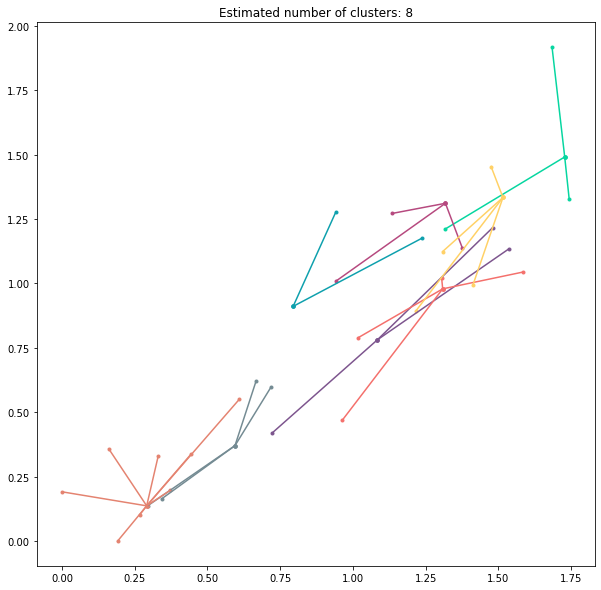

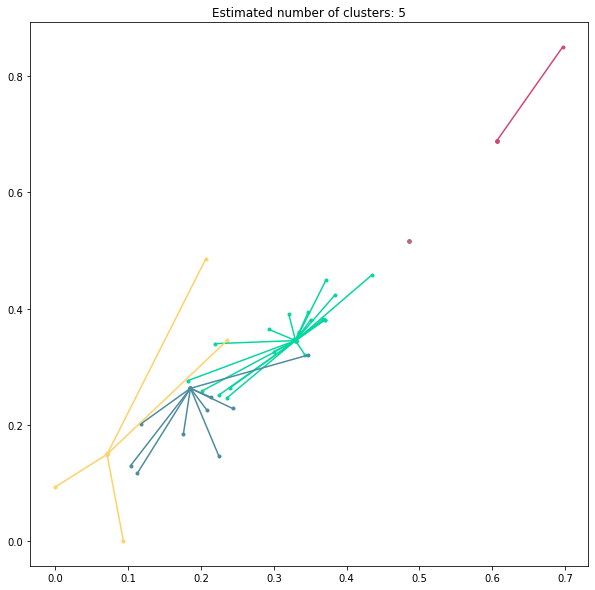

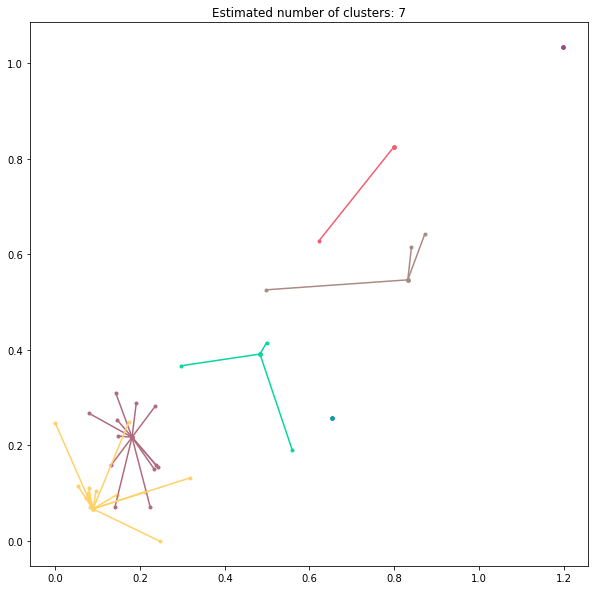

In [58]:
labels_b=ap_cluster_visual(cmat_before, -10)
# plt.savefig(os.path.join(save_dir,'ap_clust_before.png'), dpi=300, bbox_inches='tight')
labels_d=ap_cluster_visual(cmat_during, -2)
# plt.savefig(os.path.join(save_dir,'ap_clust_during.png'), dpi=300, bbox_inches='tight')
labels_a=ap_cluster_visual(cmat_after, -3)
# plt.savefig(os.path.join(save_dir,'ap_clust_after.png'), dpi=300, bbox_inches='tight')

In [80]:
def sort_by_clust_size(avg_mat, labels, do_clust=False):
    to_sort=avg_mat 
    temp_clustered={}
    clus_num=list(np.unique(labels))
    for val in clus_num:
        temp_clustered[val]={}
#         print(val)
        for i, anat in enumerate(to_sort):
    #         print(i, anat)
            cluster_val=labels[i]
            if cluster_val==val:
                temp_clustered[val][anat]=to_sort[anat]

#     for key in temp_clustered:
#         print(f'Cluster {key}: {temp_clustered[key].keys()}')

    temp_clustered_final={}
    cluster_dict=temp_clustered
    # name_mean=[]
    for cluster in temp_clustered:
        temp_clustered_final[cluster]={}
        sort_idx=np.argsort(np.mean(list(cluster_dict[cluster].values()), axis=1))
#         print(sort_idx)
        names=list(cluster_dict[cluster].keys())
        for idx in sort_idx:
            key=names[idx]
    #         print(key)
            temp_clustered_final[cluster][key]=cluster_dict[cluster][key]
    #         name_mean.append(key)

    area_size=[]
    for clust in temp_clustered_final:
#         print(list(temp_clustered_final[clust].keys()))
        area_size.append(len(temp_clustered_final[clust].keys()))
    order=np.argsort(area_size)
#     print(order)

    ap_clustered={}
    for i,val in enumerate(order):
        c=temp_clustered_final[val]
        print(f'Cluster {val}: {list(temp_clustered_final[val].keys())}')
        if do_clust:
            ap_clustered[i]={}
        for name in c:
            if do_clust:
                ap_clustered[i][name]=c[name]
            else:
                ap_clustered[name]=c[name]
        

    return ap_clustered

In [79]:
print('DURING')
ap_clustered_d=sort_by_clust_size(avg_behave,labels_d)

print('BEFORE')
ap_clustered_b=sort_by_clust_size(avg_behave,labels_b)

print('AFTER')
ap_clustered_a=sort_by_clust_size(avg_behave,labels_a)

DURING
Cluster 2: ['MB_VL']
Cluster 3: ['MB_CA', 'MB_ML']
Cluster 4: ['NO', 'BU', 'EB', 'FB', 'SMP']
Cluster 1: ['FLA', 'GOR', 'SPS', 'PRW', 'ICL', 'SAD', 'IB', 'PB', 'GNG', 'ATL']
Cluster 0: ['IPS', 'SLP', 'VES', 'PLP', 'SCL', 'IVLP', 'AVLP', 'LO', 'LH', 'LAL', 'MB_PED', 'PVLP', 'AOTU', 'LP', 'AMMC', 'MED', 'SIP', 'AL', 'CRE', 'EPA', 'CAN']
BEFORE
Cluster 1: ['MB_VL', 'IB', 'PB']
Cluster 0: ['PLP', 'SPS', 'LO', 'EPA']
Cluster 4: ['IVLP', 'PVLP', 'LH', 'GNG']
Cluster 5: ['FLA', 'SCL', 'ICL', 'MED']
Cluster 2: ['GOR', 'MB_CA', 'BU', 'AOTU', 'AMMC']
Cluster 6: ['VES', 'SLP', 'AVLP', 'MB_PED', 'SIP']
Cluster 7: ['IPS', 'PRW', 'LP', 'ATL', 'CAN']
Cluster 3: ['NO', 'LAL', 'MB_ML', 'SAD', 'EB', 'FB', 'SMP', 'AL', 'CRE']
AFTER
Cluster 1: ['PB']
Cluster 4: ['MB_VL']
Cluster 5: ['IB', 'ATL']
Cluster 0: ['IPS', 'FLA', 'GOR', 'SAD']
Cluster 2: ['MB_CA', 'PRW', 'GNG', 'SMP']
Cluster 3: ['VES', 'SLP', 'IVLP', 'SCL', 'BU', 'MB_PED', 'MB_ML', 'ICL', 'AMMC', 'EB', 'SIP', 'EPA', 'CRE']
Cluster 6: ['NO'

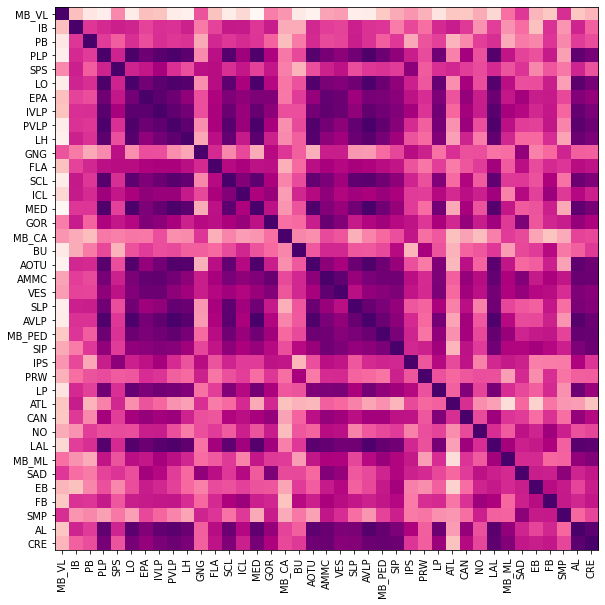

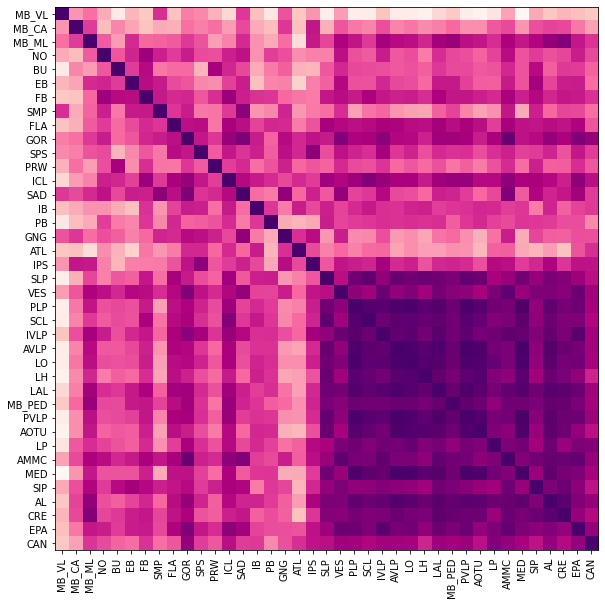

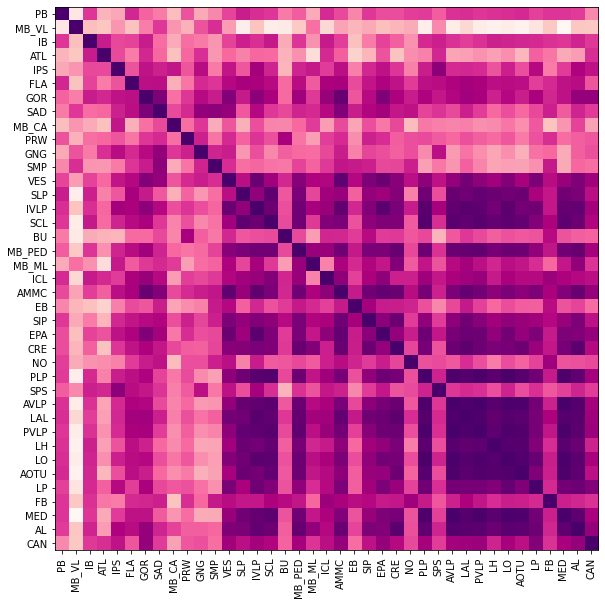

In [61]:
cmat_ap_b=np.corrcoef(list(ap_clustered_b.values()))
cmat_ap_d=np.corrcoef(list(ap_clustered_d.values()))
cmat_ap_a=np.corrcoef(list(ap_clustered_a.values()))

fig1,axs1 = plt.subplots(figsize=(10,10))
cov1=axs1.imshow(cmat_ap_b, cmap='RdPu');
axs1.label_outer();
axs1.set_aspect(1);
axs1.set_yticks(np.arange(len(list(ap_clustered_b.keys()))));
axs1.set_yticklabels(list(ap_clustered_b.keys()));
axs1.set_xticks(np.arange(len(list(ap_clustered_b.keys()))));
axs1.set_xticklabels(list(ap_clustered_b.keys()), rotation='vertical');
# axs1.set_title('BEFORE')
# plt.savefig(os.path.join(save_dir,'corr_ap_clust_before.png'), dpi=300, bbox_inches='tight')

fig2,axs2 = plt.subplots(figsize=(10,10))
cov2=axs2.imshow(cmat_ap_d, cmap='RdPu');
axs2.label_outer();
axs2.set_aspect(1);
axs2.set_yticks(np.arange(len(list(ap_clustered_d.keys()))));
axs2.set_yticklabels(list(ap_clustered_d.keys()));
axs2.set_xticks(np.arange(len(list(ap_clustered_d.keys()))));
axs2.set_xticklabels(list(ap_clustered_d.keys()), rotation='vertical');
# axs2.set_title('DURING')
# plt.savefig(os.path.join(save_dir,'corr_ap_clust_during.png'), dpi=300, bbox_inches='tight')

fig3,axs3 = plt.subplots(figsize=(10,10))
cov3=axs3.imshow(cmat_ap_a, cmap='RdPu');
axs3.label_outer();
axs3.set_aspect(1);
axs3.set_yticks(np.arange(len(list(ap_clustered_a.keys()))));
axs3.set_yticklabels(list(ap_clustered_a.keys()));
axs3.set_xticks(np.arange(len(list(ap_clustered_a.keys()))));
axs3.set_xticklabels(list(ap_clustered_a.keys()), rotation='vertical');
# axs3.set_title('AFTER')
# plt.savefig(os.path.join(save_dir,'corr_ap_clust_after.png'), dpi=300, bbox_inches='tight')

In [62]:
def place_roi_groups_on_canvas(explosion_rois, roi_masks, roi_contours, data_to_plot, input_canvas, vmax, cmap, rois, diverging=False):
    full_y_mid = int(input_canvas.shape[0]/2)
    full_x_mid = int(input_canvas.shape[1]/2)
    
    for roi_group in explosion_rois:
        
        x_shift = explosion_rois[roi_group]['x_shift']
        y_shift = explosion_rois[roi_group]['y_shift']
        
        roi_data = []
        left_edges = []
        right_edges = []
        bottom_edges = []
        top_edges = []
        
        for roi in explosion_rois[roi_group]['rois']:
            mask = roi_masks[roi]
            name=explosion_rois[roi_group]['rois'][roi]
            last = name.split("_")[-1]
            removed=name.replace(f'_{last}', '')
            if removed in rois:
                masked_roi = mask*1
            else:
                # Change this line: set to NaN instead of 0
                masked_roi = mask*np.nan

            ### maximum projection along z-axis
            # Use nanmax and nanmin to handle NaN values properly
            maxs = np.nanmax(masked_roi,axis=2)
            mins = np.nanmin(masked_roi,axis=2)
            maxs[np.where(np.abs(mins)>maxs)] = mins[np.where(np.abs(mins)>maxs)]
            roi_data.append(maxs)
            
            left_edges.append(roi_contours[roi]['left_edge'])
            right_edges.append(roi_contours[roi]['right_edge'])
            top_edges.append(roi_contours[roi]['top_edge'])
            bottom_edges.append(roi_contours[roi]['bottom_edge'])
        
        # get extreme edges from all rois used
        left_edge = np.min(left_edges) - 1
        right_edge = np.max(right_edges) + 1
        top_edge = np.min(top_edges) - 1
        bottom_edge = np.max(bottom_edges) + 1
        
        ### Use nanmax and nanmin here too
        maxs = np.nanmax(np.asarray(roi_data),axis=0)
        mins = np.nanmin(np.asarray(roi_data),axis=0)
        maxs[np.where(np.abs(mins)>maxs)] = mins[np.where(np.abs(mins)>maxs)]
        roi_datas = maxs

        ### cutout this grouping
        data_map = np.swapaxes(roi_datas[top_edge:bottom_edge,left_edge:right_edge],0,1)

        mycmap = matplotlib.cm.get_cmap(cmap)
        mycmap.set_bad(alpha=0)  # This will now work with NaN values

        if diverging:
            norm = matplotlib.colors.Normalize(vmin=-vmax, vmax=vmax)
            data_map = norm(data_map)
        else:
            data_map = data_map/vmax
        
        data_map = mycmap(data_map)  # Keep alpha channel this time

        dims = brainsss.get_dim_info(data_map, full_x_mid, full_y_mid)

        ### ADD TO CANVAS - handle alpha channel
        canvas_region = input_canvas[dims['top']+y_shift:dims['bottom']+y_shift,
                                   dims['left']+x_shift:dims['right']+x_shift, :3]
        
        # Only update pixels where alpha > 0 (non-transparent)
        alpha_mask = data_map[..., 3] > 0
        canvas_region[alpha_mask] = data_map[alpha_mask, :3]
        
        ### ADD CONTOUR TO CANVAS
        for roi in explosion_rois[roi_group]['rois']:
            contour = roi_contours[roi]['contour']
            contour = np.swapaxes(contour[top_edge:bottom_edge,left_edge:right_edge],0,1)
            ys = np.where(contour[:,:,0]>0)[0] + dims['top'] + y_shift
            xs = np.where(contour[:,:,0]>0)[1] + dims['left'] + x_shift
            input_canvas[ys,xs]=0
    return input_canvas

In [72]:
data=full_res['total']
print(data.shape)

(24, 314, 146, 91)


In [73]:
rainbow_color=np.asarray(['#EF476F', '#F78C6B', '#FFD166', '#06D6A0', '#118AB2', '#6A4C93'])
this_color=['#FFFFFF','#EF476F']
cmap_this_color = matplotlib.colors.LinearSegmentedColormap.from_list(
    'cmap', this_color)

In [74]:
rois=['MB_VL']
input_canvas = np.ones((500,500,3)) #+.5 #.5 for diverging
data_to_plot = data[15][:,:,::-1]
vmax = 0.5
explosion_map=place_roi_groups_on_canvas(explosion_rois,roi_masks,
                           roi_contours,
                           data_to_plot,
                           input_canvas,
                           vmax=0.1,
                           rois=rois,
                           cmap=cmap_this_color, diverging=False)

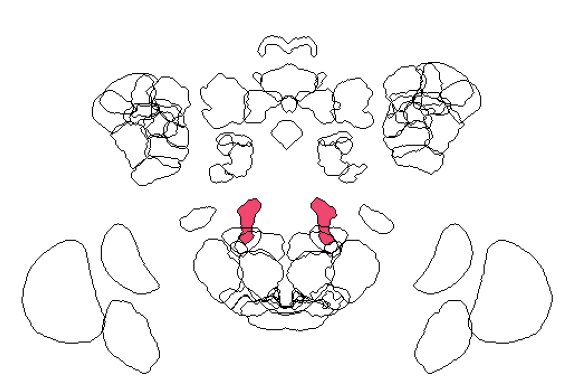

In [75]:

plt.figure(figsize=(10,10));
plt.imshow(explosion_map[170:,:]);
plt.axis('off');
# plt.savefig(os.path.join(save_dir,f'{rois[0]}_map.png'), dpi=300, bbox_inches='tight', transparent=True)

In [77]:
ap_clustered_d.keys()

dict_keys(['MB_VL', 'MB_CA', 'MB_ML', 'NO', 'BU', 'EB', 'FB', 'SMP', 'FLA', 'GOR', 'SPS', 'PRW', 'ICL', 'SAD', 'IB', 'PB', 'GNG', 'ATL', 'IPS', 'SLP', 'VES', 'PLP', 'SCL', 'IVLP', 'AVLP', 'LO', 'LH', 'LAL', 'MB_PED', 'PVLP', 'AOTU', 'LP', 'AMMC', 'MED', 'SIP', 'AL', 'CRE', 'EPA', 'CAN'])

In [83]:
print('DURING')
ap_clustered_d=sort_by_clust_size(avg_behave,labels_d,do_clust=True)

print('BEFORE')
ap_clustered_b=sort_by_clust_size(avg_behave,labels_b,do_clust=True)

print('AFTER')
ap_clustered_a=sort_by_clust_size(avg_behave,labels_a,do_clust=True)

DURING
Cluster 2: ['MB_VL']
Cluster 3: ['MB_CA', 'MB_ML']
Cluster 4: ['NO', 'BU', 'EB', 'FB', 'SMP']
Cluster 1: ['FLA', 'GOR', 'SPS', 'PRW', 'ICL', 'SAD', 'IB', 'PB', 'GNG', 'ATL']
Cluster 0: ['IPS', 'SLP', 'VES', 'PLP', 'SCL', 'IVLP', 'AVLP', 'LO', 'LH', 'LAL', 'MB_PED', 'PVLP', 'AOTU', 'LP', 'AMMC', 'MED', 'SIP', 'AL', 'CRE', 'EPA', 'CAN']
BEFORE
Cluster 1: ['MB_VL', 'IB', 'PB']
Cluster 0: ['PLP', 'SPS', 'LO', 'EPA']
Cluster 4: ['IVLP', 'PVLP', 'LH', 'GNG']
Cluster 5: ['FLA', 'SCL', 'ICL', 'MED']
Cluster 2: ['GOR', 'MB_CA', 'BU', 'AOTU', 'AMMC']
Cluster 6: ['VES', 'SLP', 'AVLP', 'MB_PED', 'SIP']
Cluster 7: ['IPS', 'PRW', 'LP', 'ATL', 'CAN']
Cluster 3: ['NO', 'LAL', 'MB_ML', 'SAD', 'EB', 'FB', 'SMP', 'AL', 'CRE']
AFTER
Cluster 1: ['PB']
Cluster 4: ['MB_VL']
Cluster 5: ['IB', 'ATL']
Cluster 0: ['IPS', 'FLA', 'GOR', 'SAD']
Cluster 2: ['MB_CA', 'PRW', 'GNG', 'SMP']
Cluster 3: ['VES', 'SLP', 'IVLP', 'SCL', 'BU', 'MB_PED', 'MB_ML', 'ICL', 'AMMC', 'EB', 'SIP', 'EPA', 'CRE']
Cluster 6: ['NO'

In [103]:
to_sort=ap_clustered_a
explosions=[]
for key in to_sort:
    print(f'Cluster {key}: {to_sort[key].keys()}')
    rois=list(to_sort[key].keys())
    rainbow_color=np.asarray(['#EF476F', '#F78C6B', '#FFD166', '#06D6A0', '#118AB2', '#6A4C93','#6E0D25','#357D76'])
    this_color=['#FFFFFF',rainbow_color[key]]
    cmap_this_color = matplotlib.colors.LinearSegmentedColormap.from_list(
        'cmap', this_color)
    input_canvas = np.ones((500,500,3)) #+.5 #.5 for diverging
    data_to_plot = data[15][:,:,::-1]
    vmax = 0.5
    explosion_map=place_roi_groups_on_canvas(explosion_rois,roi_masks,
                               roi_contours,
                               data_to_plot,
                               input_canvas,
                               vmax=0.1,
                               rois=rois,
                               cmap=cmap_this_color, diverging=False)
#     explosion_map[explosion_map<=0] = np.nan
    explosions.append(explosion_map)

Cluster 0: dict_keys(['PB'])
Cluster 1: dict_keys(['MB_VL'])
Cluster 2: dict_keys(['IB', 'ATL'])
Cluster 3: dict_keys(['IPS', 'FLA', 'GOR', 'SAD'])
Cluster 4: dict_keys(['MB_CA', 'PRW', 'GNG', 'SMP'])
Cluster 5: dict_keys(['VES', 'SLP', 'IVLP', 'SCL', 'BU', 'MB_PED', 'MB_ML', 'ICL', 'AMMC', 'EB', 'SIP', 'EPA', 'CRE'])
Cluster 6: dict_keys(['NO', 'PLP', 'SPS', 'AVLP', 'LAL', 'PVLP', 'LH', 'LO', 'AOTU', 'LP', 'FB', 'MED', 'AL', 'CAN'])


In [104]:
final=np.nanmin(explosions, axis=0)

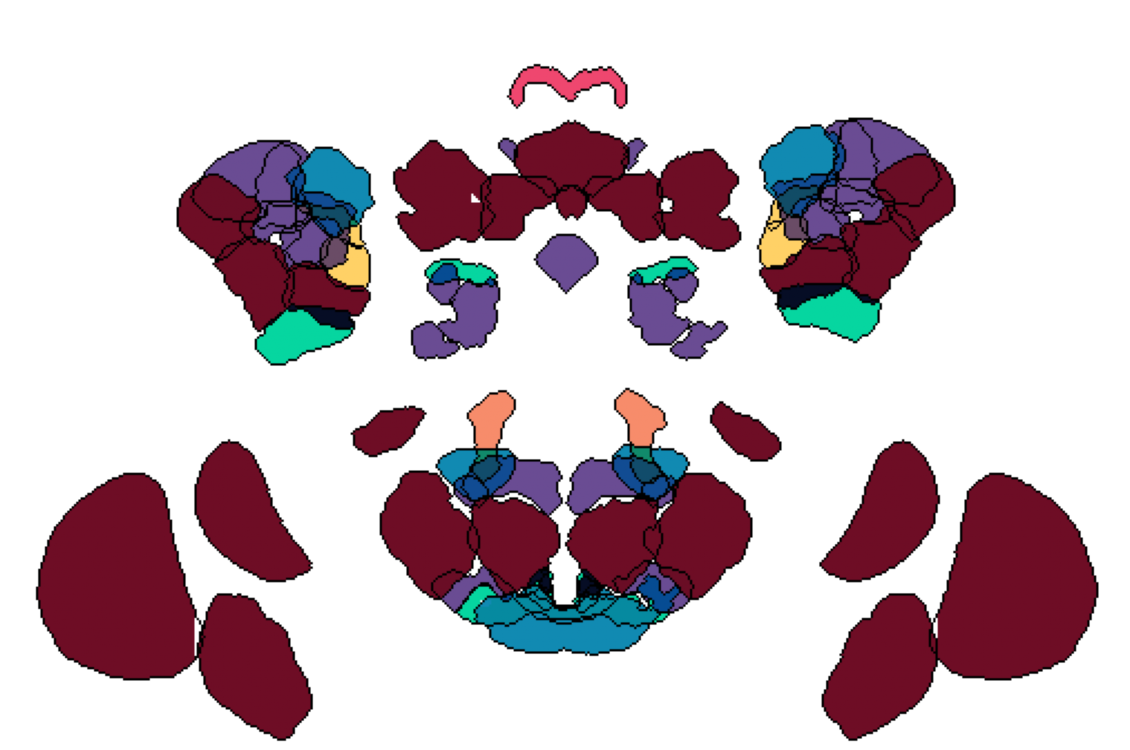

In [105]:
fig,axs=plt.subplots(figsize=(20,20));
axs.imshow(final[170:,:]);
axs.axis('off');
# for i in range(len(area_clustered)):
#     axs.imshow(explosions[i][170:,:]);
#     axs.axis('off');
plt.savefig(os.path.join(save_dir,'after_clusters_on_map.png'), dpi=300, bbox_inches='tight', transparent=True)

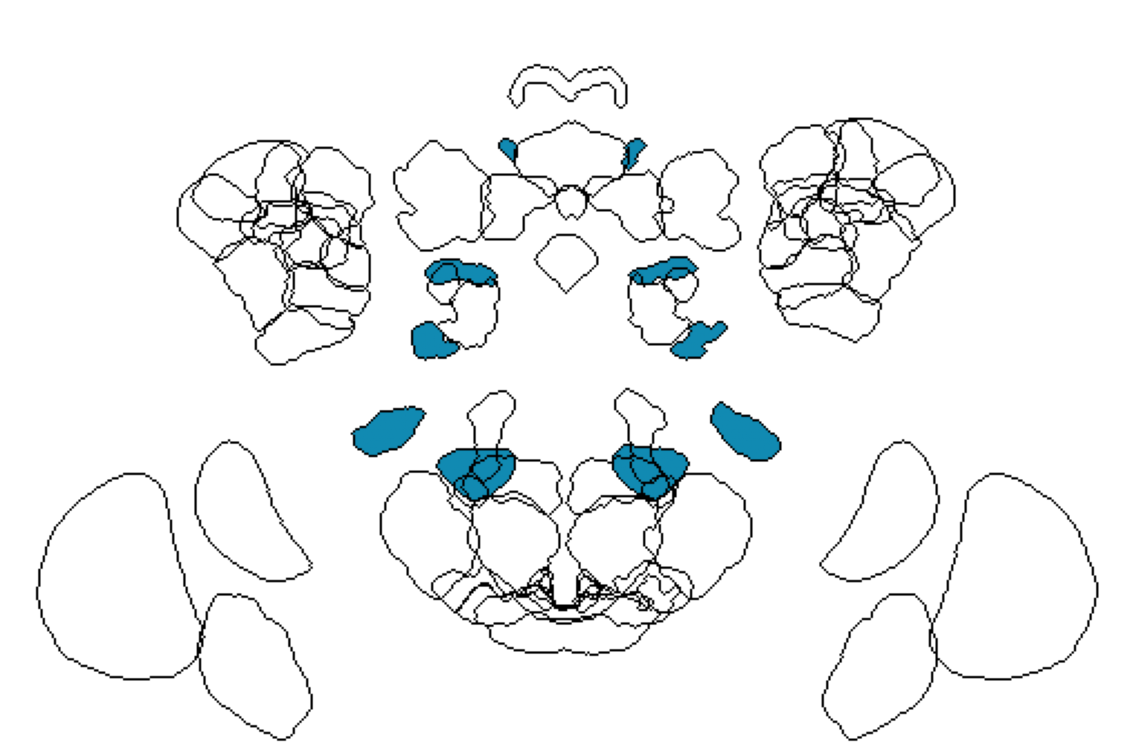

In [102]:
fig,axs=plt.subplots(figsize=(20,20));
axs.imshow(explosions[4][170:,:]);
axs.axis('off');

In [82]:
for behave in full_res:
    full_res[behave]=np.moveaxis(full_res[behave], 0,-1)

In [83]:
color_map_color_1=np.asarray(['#780000','#C1121F','#E0898F','#F0C4C7','#FFFFFF','#D9E6EF','#B3CDDE','#669BBC', '#003049'])[::-1]
cmap_personal = matplotlib.colors.LinearSegmentedColormap.from_list(
    'cmap', color_map_color_1)

top_color=np.asarray(['#780000','#C1121F','#E0898F','#F0C4C7'])[::-1]
bottom=np.asarray(['#D9E6EF','#B3CDDE','#669BBC', '#003049'])[::-1]
top_half_spect = matplotlib.colors.LinearSegmentedColormap.from_list(
    'top_half_spect', top_color)
bottom_half_spect = matplotlib.colors.LinearSegmentedColormap.from_list(
    'bottom_half_spect', bottom)

# Register the new colormap
plt.register_cmap(cmap=top_half_spect)
plt.register_cmap(cmap=bottom_half_spect)

In [87]:
def mean_edges(flattened):
    mean_line=np.nanmean(flattened)
    std=np.nanstd(flattened)
    neg_edge=mean_line-std
    pos_edge=mean_line+std
    return mean_line, neg_edge, pos_edge
def get_vals_anat(roi, roi_label_dict, roi_masks, traces, behavior, roi_contours, vmax, thresh=None):
    x_shift = roi_label_dict[roi]['shifts'][0]
    y_shift = roi_label_dict[roi]['shifts'][1]

    left_edges = []
    right_edges = []
    bottom_edges = []
    top_edges = []
    
    roi_label=roi_label_dict[roi]['label']
    mask = roi_masks[roi_label]
    masked_roi = np.where(mask[...,None]==True, traces[behavior], np.nan)
#     t,x,y,z=np.shape(masked_roi)
    x,y,z,t=np.shape(traces[behavior])
#     print(x,y,z,t)
#     flatten=np.asarray(masked_roi).reshape(x*y*z,t)
    flatten=np.asarray(traces[behavior]).reshape(x*y*z,t)
    m,n,p=mean_edges(flatten)
    
    if thresh=='pos':
        total_masked=np.where(masked_roi>p*1,masked_roi, np.nan)
#         print(p)
    elif thresh=='neg':
        total_masked=np.where(masked_roi<n*1,masked_roi, np.nan)
#         print(n)
    else:
        total_masked=np.where(masked_roi>thresh,masked_roi, np.nan)
    
    left_edges.append(roi_contours[roi_label]['left_edge'])
    right_edges.append(roi_contours[roi_label]['right_edge'])
    top_edges.append(roi_contours[roi_label]['top_edge'])
    bottom_edges.append(roi_contours[roi_label]['bottom_edge'])
    
    # get extreme edges from all rois used
    left_edge = np.min(left_edges) - 1
    right_edge = np.max(right_edges) + 1
    top_edge = np.min(top_edges) - 1
    bottom_edge = np.max(bottom_edges) + 1
    
    final=total_masked[top_edge:bottom_edge,left_edge:right_edge]
#     if vmax!=None:
#         norm = matplotlib.colors.Normalize(vmin=-vmax, vmax=vmax)
#         final = norm(final)

    contour = roi_contours[roi_label]['contour'][...,0]
    contour = contour[top_edge:bottom_edge,left_edge:right_edge]
    
    return final, contour

In [85]:
roi_label_dict={}
for area in explosion_rois:
    rois=explosion_rois[area]['rois']
    shifts=[explosion_rois[area]['x_shift'], explosion_rois[area]['y_shift']]
    for roi in rois:
        name=rois[roi]
        if area!=name:
            group=area
        else:
            group=name
        roi_label_dict[name]={}
        roi_label_dict[name]['label']=roi
        roi_label_dict[name]['shifts']=shifts
        roi_label_dict[name]['group']=group

In [86]:
anat='MB_VL_R'
behave='total'
direction='pos'
total_anat_max, contour_max=get_vals_anat(anat, roi_label_dict, roi_masks, full_res, behave, roi_contours, vmax=None, thresh=direction)

314 146 91 24


In [88]:
direction='neg'
total_anat_min, contour_min=get_vals_anat(anat, roi_label_dict, roi_masks, full_res, behave, roi_contours, vmax=None, thresh=direction)

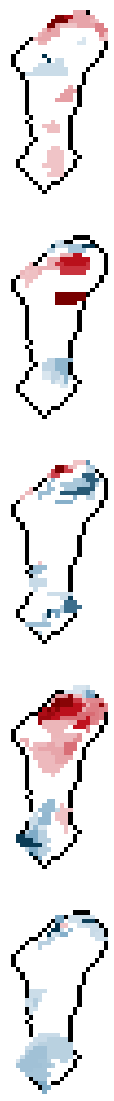

In [97]:
# ts=[6,7,8,9,10,11,12,13,14,15]
ts=[2,3,4,5,6]
num_reg=np.shape(ts)[0]
fig, axs=plt.subplots(num_reg,1,figsize=(20,20))
for j,t in enumerate(ts):
#     print(f'j:{j}, t:{t}')
    
    x,y=np.nanmax(total_anat_max[...,t],axis=-1).shape
    max_t=np.ravel(np.nanmax(total_anat_max[...,t],axis=-1))
    min_t=np.ravel(np.nanmin(total_anat_min[...,t],axis=-1))
    for i in range(min_t.shape[0]):
        if ~np.isnan(max_t[i]) and ~np.isnan(min_t[i]):
            if np.abs(max_t[i])>np.abs(min_t[i]):
                min_t[i]=np.nan
            elif np.abs(max_t[i])<np.abs(min_t[i]):
                max_t[i]=np.nan
    final_max=max_t.reshape(x,y)
    final_min=min_t.reshape(x,y)
    axs[j].imshow(contour_max.T, 'Greys');

    axs[j].imshow(final_min.T, cmap=bottom_half_spect);
    axs[j].imshow(final_max.T,cmap=top_half_spect);

    axs[j].axis('off');
# plt.savefig(os.path.join(save_dir,f'{anat}_{step_size}_{t}_v.png'), dpi=300, bbox_inches='tight')
    # plt.savefig(os.path.join(save_dir,f'{anat}_{pix_type}_{step_size}_{t}.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)